In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import sys
import glob
from model.data.load_data import *


In [3]:
domain = "NORTHAFRICA"
date = "201407"

In [4]:
fp_datadir = f"/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/{domain}/LMP-10magl_{domain}_{date}.nc"
met_datadir = f"/group/chemistry/acrg/met_archive/UM/{domain}/{domain}_Met_{date}.nc"

# Load the data
fp_ds = xr.open_dataset(fp_datadir)
met_ds = xr.open_dataset(met_datadir)

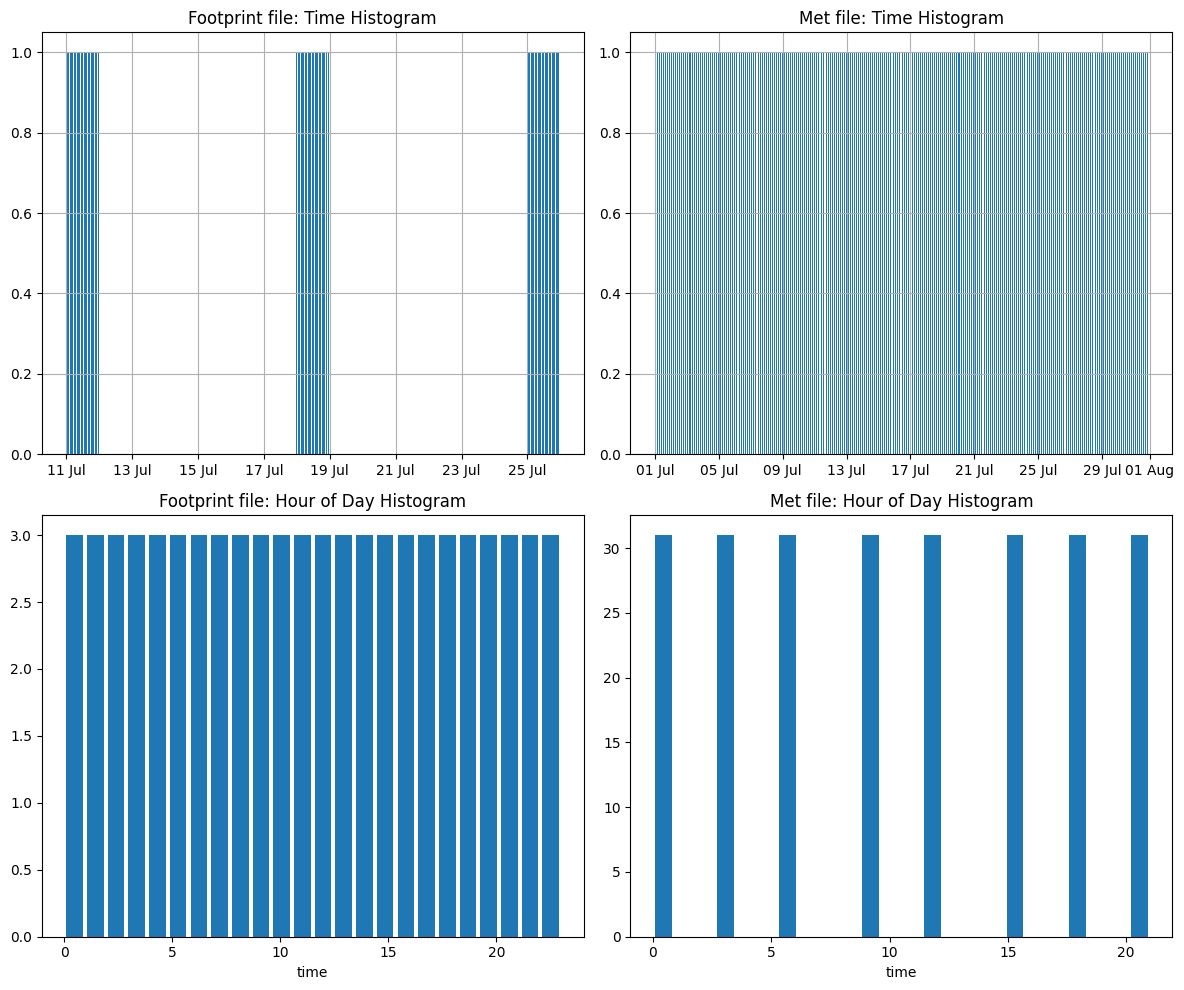

In [11]:
# Visualise fp and met datasets

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# Example plots using ds and fp_ds time histograms
fp_ds['time'].to_dataframe().hist(column='time',bins=500, ax=axs[0, 0])
axs[0, 0].set_title('Footprint file: Time Histogram')

met_ds['time'].to_dataframe().hist(column='time', bins=500, ax=axs[0, 1])
axs[0, 1].set_title('Met file: Time Histogram')

fp_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 0])
axs[1, 0].set_title('Footprint file: Hour of Day Histogram')

met_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 1])
axs[1, 1].set_title('Met file: Hour of Day Histogram')

date_formatter = mdates.DateFormatter('%d %b')  # Shows e.g. "23 May"
axs[0, 0].xaxis.set_major_formatter(date_formatter)
axs[0, 1].xaxis.set_major_formatter(date_formatter)
plt.tight_layout()
plt.show()

In [6]:
def interpolate_met_time(ds, interval_minutes=60):
    """
    Interpolate the time dimension of a met xarray.Dataset to a regular interval.

    Parameters
    ----------
    ds : xarray.Dataset
        The meteorological dataset with a 'time' coordinate.
    interval_minutes : int
        Desired interval in minutes for interpolation.

    Returns
    -------
    xarray.Dataset
        Dataset interpolated to the new time grid.
    """
    # Create new time index at desired interval
    time_min = ds['time'].values[0]
    time_max = ds['time'].values[-1]
    new_time = pd.date_range(start=time_min, end=time_max, freq=f'{interval_minutes}min')

    # Interpolate all variables along the time dimension
    ds_interp = ds.interp(time=new_time)
    return ds_interp

In [7]:
met_interp = interpolate_met_time(met_ds, interval_minutes=90)

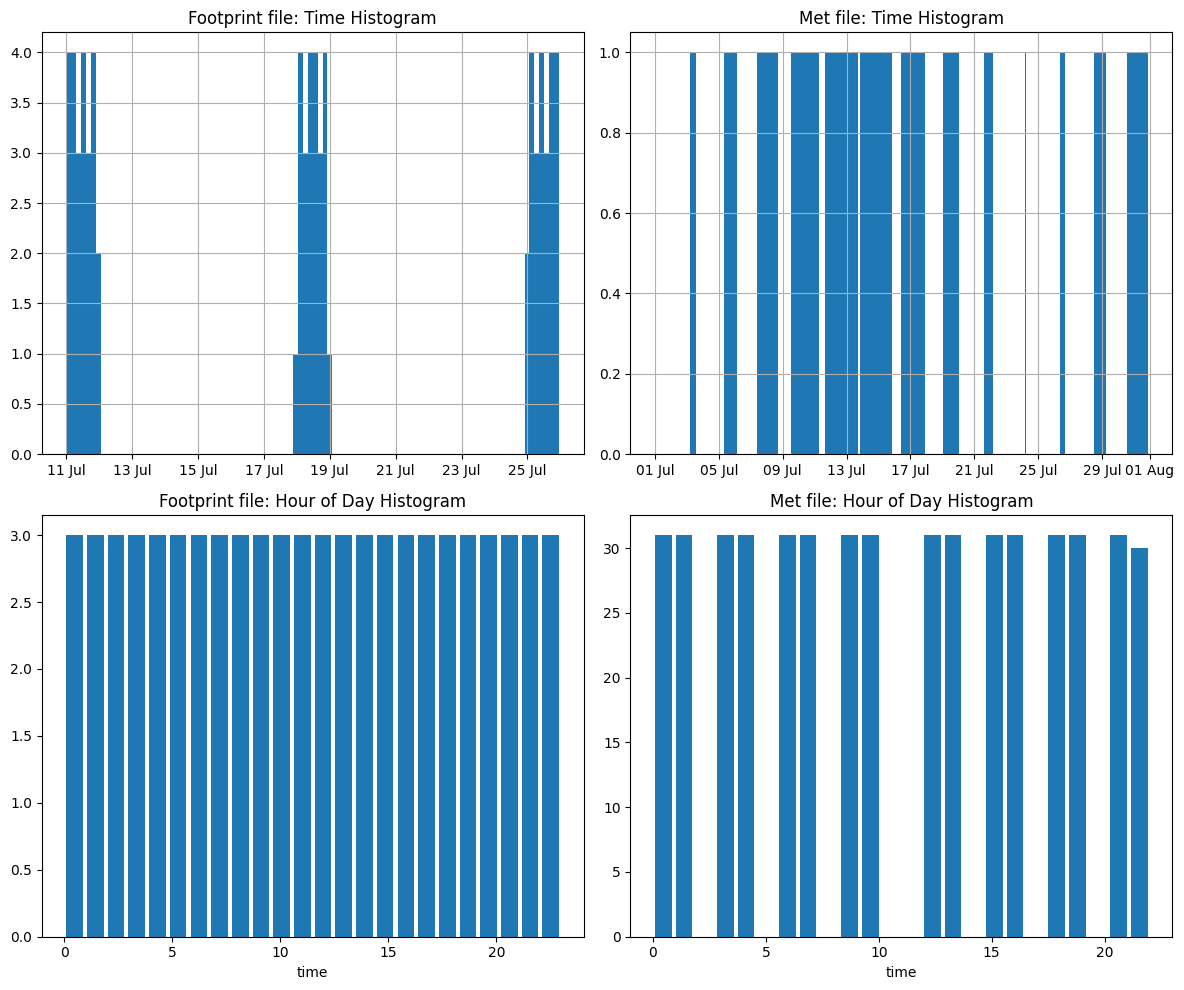

In [8]:
# Visualise fp and met datasets

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# Example plots using ds and fp_ds time histograms
fp_ds['time'].to_dataframe().hist(column='time', bins=100, ax=axs[0, 0])
axs[0, 0].set_title('Footprint file: Time Histogram')

met_interp['time'].to_dataframe().hist(column='time', bins=1000, ax=axs[0, 1])
axs[0, 1].set_title('Met file: Time Histogram')

fp_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 0])
axs[1, 0].set_title('Footprint file: Hour of Day Histogram')

met_interp['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 1])
axs[1, 1].set_title('Met file: Hour of Day Histogram')

axs[0, 0].xaxis.set_major_formatter(date_formatter)
axs[0, 1].xaxis.set_major_formatter(date_formatter)

plt.tight_layout()
plt.show()

# Several potential options:
1) Choose closest existing met to a fp - no interp
2) Interp to a certain frequency eg 1 hour, then choose closest fp
3) Also consider temporal frequency

Also:
1) [DONE] Visualise how much met varies over a certain period (eg within 3 hours what is the range of x_winds?)

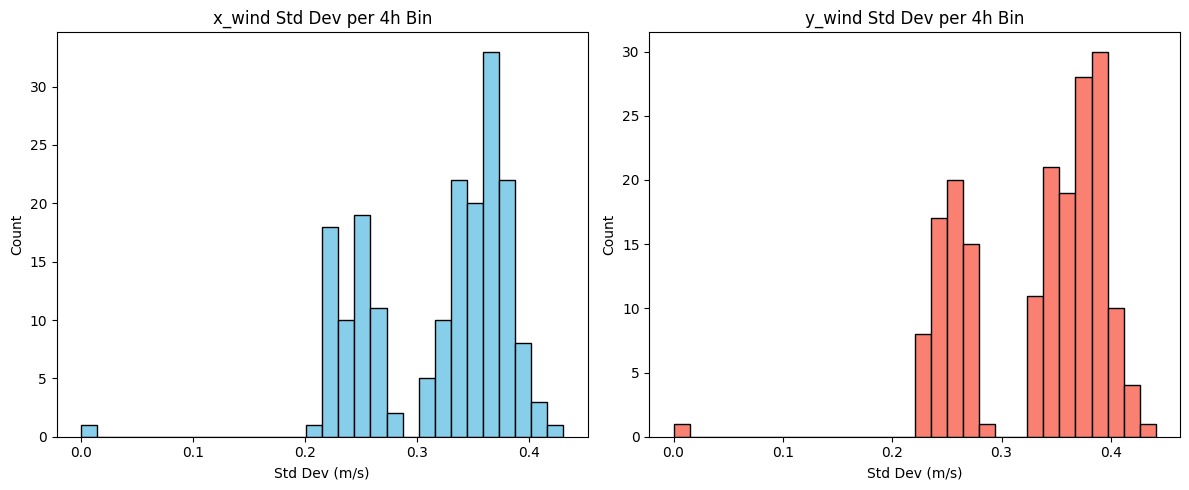

In [13]:
# Set the bin size in hours
bin_hours = 4

# Resample met_interp along the time dimension
# We'll calculate the standard deviation (variation) within each bin for x_wind and y_wind at the lowest model level
level0 = met_interp.model_level_number.values[0]

x_wind_var = met_interp['x_wind'].sel(model_level_number=level0).resample(time=f'{bin_hours}h').std(dim='time')
y_wind_var = met_interp['y_wind'].sel(model_level_number=level0).resample(time=f'{bin_hours}h').std(dim='time')

# For simplicity, take the mean variation over all lat/lon for each bin
x_wind_var_mean = x_wind_var.mean(dim=['latitude', 'longitude']).values
y_wind_var_mean = y_wind_var.mean(dim=['latitude', 'longitude']).values

# Plot histograms of the variations
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].hist(x_wind_var_mean, bins=30, color='skyblue', edgecolor='k')
axs[0].set_title(f'x_wind Std Dev per {bin_hours}h Bin')
axs[0].set_xlabel('Std Dev (m/s)')
axs[0].set_ylabel('Count')

axs[1].hist(y_wind_var_mean, bins=30, color='salmon', edgecolor='k')
axs[1].set_title(f'y_wind Std Dev per {bin_hours}h Bin')
axs[1].set_xlabel('Std Dev (m/s)')
axs[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

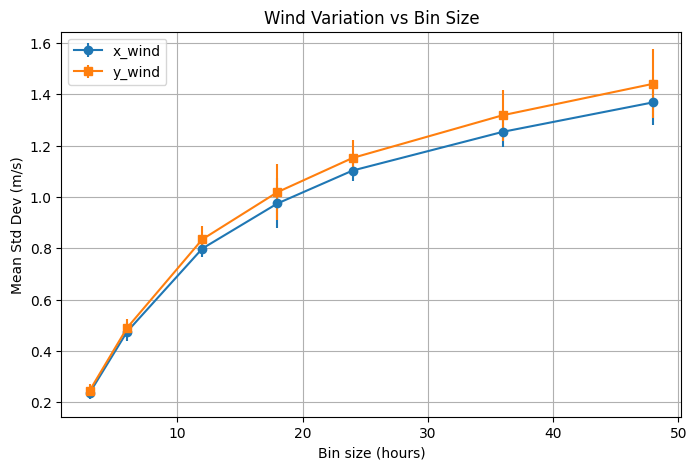

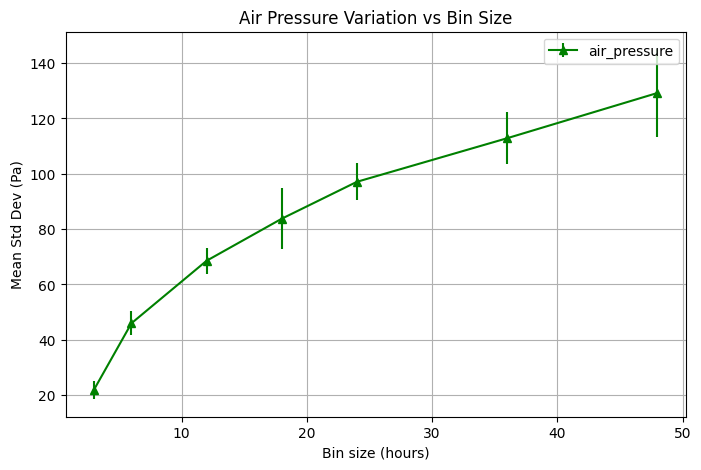

In [14]:
# Loop over a range of bin_hours and collect mean/std of wind and pressure variations
bin_hours_list = [3, 6, 12, 18, 24, 36, 48]
x_wind_means = []
x_wind_stds = []
y_wind_means = []
y_wind_stds = []

level0 = met_interp.model_level_number.values[0]

for bh in bin_hours_list:
    x_var = met_interp['x_wind'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    y_var = met_interp['y_wind'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    x_mean = x_var.mean(dim=['latitude', 'longitude']).values
    y_mean = y_var.mean(dim=['latitude', 'longitude']).values
    x_wind_means.append(np.mean(x_mean))
    x_wind_stds.append(np.std(x_mean))
    y_wind_means.append(np.mean(y_mean))
    y_wind_stds.append(np.std(y_mean))

# Plot summary of variation vs bin_hours
plt.figure(figsize=(8, 5))
plt.errorbar(bin_hours_list, x_wind_means, yerr=x_wind_stds, marker='o', label='x_wind')
plt.errorbar(bin_hours_list, y_wind_means, yerr=y_wind_stds, marker='s', label='y_wind')
plt.xlabel('Bin size (hours)')
plt.ylabel('Mean Std Dev (m/s)')
plt.title('Wind Variation vs Bin Size')
plt.legend()
plt.grid(True)

# Repeat the same analysis for air_pressure at the lowest model level
air_pressure_means = []
air_pressure_stds = []

for bh in bin_hours_list:
    ap_var = met_interp['air_pressure'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    ap_mean = ap_var.mean(dim=['latitude', 'longitude']).values
    air_pressure_means.append(np.mean(ap_mean))
    air_pressure_stds.append(np.std(ap_mean))

plt.figure(figsize=(8, 5))
plt.errorbar(bin_hours_list, air_pressure_means, yerr=air_pressure_stds, marker='^', label='air_pressure', color='green')
plt.xlabel('Bin size (hours)')
plt.ylabel('Mean Std Dev (Pa)')
plt.title('Air Pressure Variation vs Bin Size')
plt.legend()
plt.grid(True)
plt.show()
plt.show()

In [ ]:
# Loop over a range of bin_hours and collect mean/std of wind and pressure variations
bin_hours_list = [3, 6, 12, 18, 24, 36, 48]
x_wind_means = []
x_wind_stds = []
y_wind_means = []
y_wind_stds = []

level0 = met_interp.model_level_number.values[0]

for bh in bin_hours_list:
    x_var = met_interp['x_wind'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    y_var = met_interp['y_wind'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    x_mean = x_var.mean(dim=['latitude', 'longitude']).values
    y_mean = y_var.mean(dim=['latitude', 'longitude']).values
    x_wind_means.append(np.mean(x_mean))
    x_wind_stds.append(np.std(x_mean))
    y_wind_means.append(np.mean(y_mean))
    y_wind_stds.append(np.std(y_mean))

# Plot summary of variation vs bin_hours
plt.figure(figsize=(8, 5))
plt.errorbar(bin_hours_list, x_wind_means, yerr=x_wind_stds, marker='o', label='x_wind')
plt.errorbar(bin_hours_list, y_wind_means, yerr=y_wind_stds, marker='s', label='y_wind')
plt.xlabel('Bin size (hours)')
plt.ylabel('Mean Std Dev (m/s)')
plt.title('Wind Variation vs Bin Size')
plt.legend()
plt.grid(True)

# Repeat the same analysis for air_pressure at the lowest model level
air_pressure_means = []
air_pressure_stds = []

for bh in bin_hours_list:
    ap_var = met_interp['air_pressure'].sel(model_level_number=level0).resample(time=f'{bh}h').std(dim='time')
    ap_mean = ap_var.mean(dim=['latitude', 'longitude']).values
    air_pressure_means.append(np.mean(ap_mean))
    air_pressure_stds.append(np.std(ap_mean))

plt.figure(figsize=(8, 5))
plt.errorbar(bin_hours_list, air_pressure_means, yerr=air_pressure_stds, marker='^', label='air_pressure', color='green')
plt.xlabel('Bin size (hours)')
plt.ylabel('Mean Std Dev (Pa)')
plt.title('Air Pressure Variation vs Bin Size')
plt.legend()
plt.grid(True)
plt.show()
plt.show()

In [ ]:
For each day of the month, we will calculate the mean and standard deviation of the wind and pressure variations for each bin size. This analysis will help us visualize how the variability in wind and pressure evolves throughout the month and across different temporal resolutions. The resulting plots will provide insight into the temporal structure of meteorological variability, which is important for interpreting model results and designing further analyses.

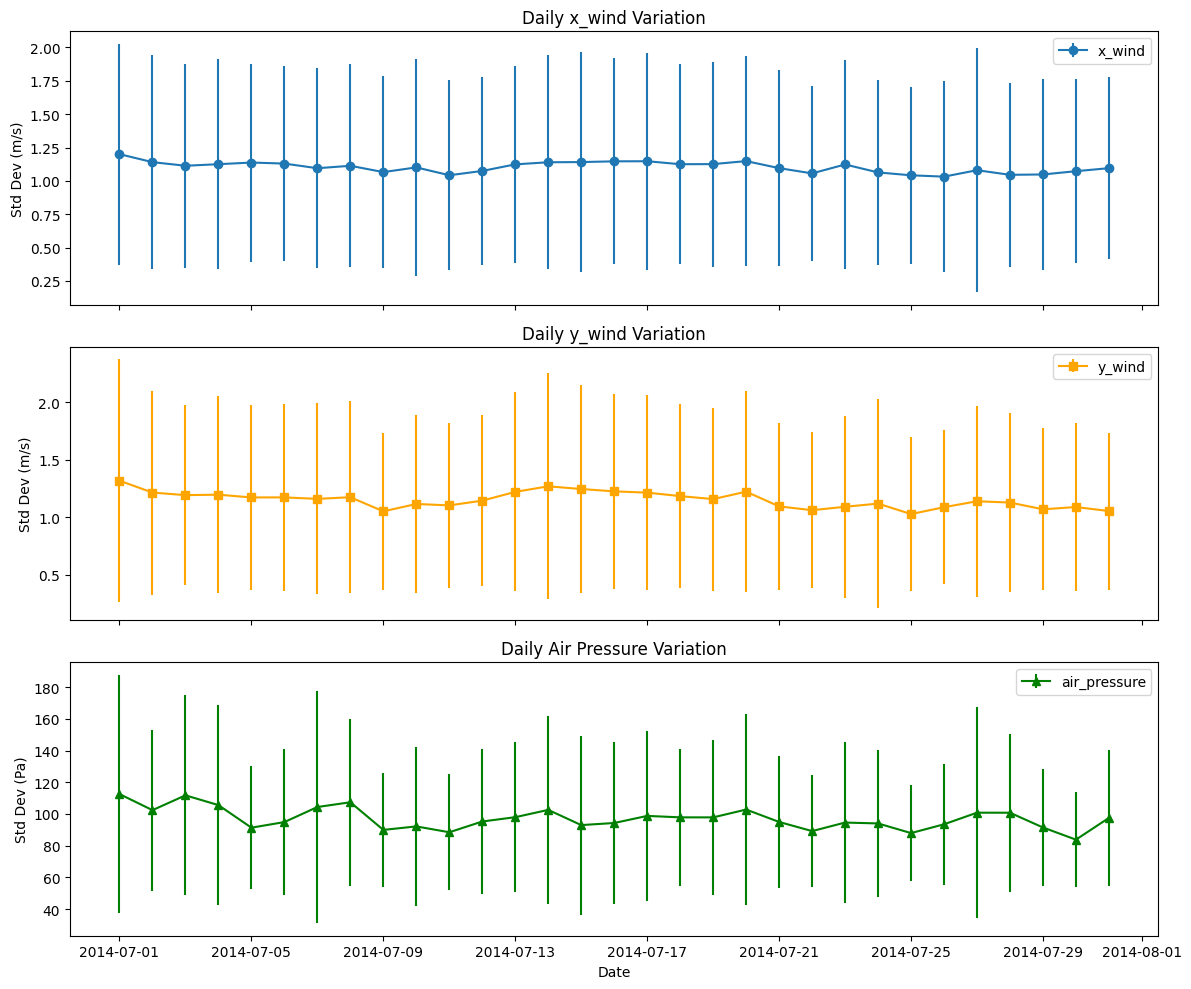

In [16]:
# Calculate daily mean and std for wind and pressure variations at the lowest model level
level0 = met_interp.model_level_number.values[0]

# Resample to daily bins and compute std (variation) for each variable
x_wind_daily_var = met_interp['x_wind'].sel(model_level_number=level0).resample(time='1D').std(dim='time')
y_wind_daily_var = met_interp['y_wind'].sel(model_level_number=level0).resample(time='1D').std(dim='time')
air_pressure_daily_var = met_interp['air_pressure'].sel(model_level_number=level0).resample(time='1D').std(dim='time')

# Mean and std over lat/lon for each day
x_wind_daily_mean = x_wind_daily_var.mean(dim=['latitude', 'longitude']).values
x_wind_daily_std = x_wind_daily_var.std(dim=['latitude', 'longitude']).values

y_wind_daily_mean = y_wind_daily_var.mean(dim=['latitude', 'longitude']).values
y_wind_daily_std = y_wind_daily_var.std(dim=['latitude', 'longitude']).values

air_pressure_daily_mean = air_pressure_daily_var.mean(dim=['latitude', 'longitude']).values
air_pressure_daily_std = air_pressure_daily_var.std(dim=['latitude', 'longitude']).values

days = x_wind_daily_var['time'].values

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].errorbar(days, x_wind_daily_mean, yerr=x_wind_daily_std, fmt='-o', label='x_wind')
axs[0].set_ylabel('Std Dev (m/s)')
axs[0].set_title('Daily x_wind Variation')
axs[0].legend()

axs[1].errorbar(days, y_wind_daily_mean, yerr=y_wind_daily_std, fmt='-s', color='orange', label='y_wind')
axs[1].set_ylabel('Std Dev (m/s)')
axs[1].set_title('Daily y_wind Variation')
axs[1].legend()

axs[2].errorbar(days, air_pressure_daily_mean, yerr=air_pressure_daily_std, fmt='-^', color='green', label='air_pressure')
axs[2].set_ylabel('Std Dev (Pa)')
axs[2].set_title('Daily Air Pressure Variation')
axs[2].legend()

axs[2].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Choose met closest in time to each fp

In [19]:
# Select the met timepoint closest in time to each of the footprints

# Calculate time differences in hours between each fp and its closest met
fp_times = fp_ds['time'].values
met_times = met_ds['time'].values

closest_indices = np.abs(met_times[:, None] - fp_times).argmin(axis=0)
selected_met_times = met_times[closest_indices]

# For each fp time, find the index of the closest met time
time_diffs = np.abs((selected_met_times - fp_times) / np.timedelta64(1, 'h'))

avg_time_diff = np.mean(time_diffs)
std_time_diff = np.std(time_diffs)

print(f"Average time difference: {avg_time_diff:.2f} hours")
print(f"Std of time difference: {std_time_diff:.2f} hours")

Average time difference: 0.67 hours
Std of time difference: 0.47 hours


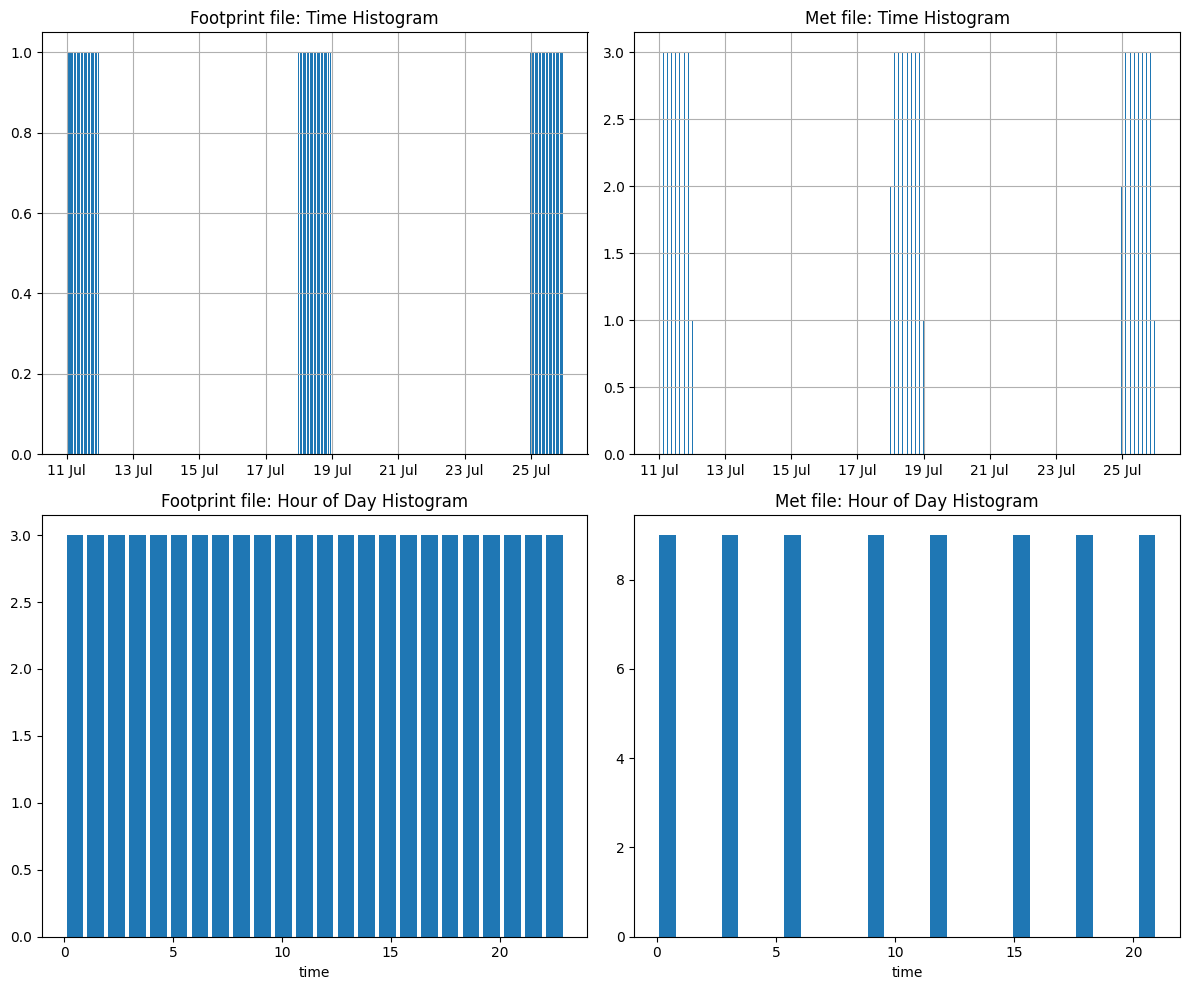

In [20]:
# Visualise fp and met datasets

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# Example plots using ds and fp_ds time histograms
fp_ds['time'].to_dataframe().hist(column='time',bins=500, ax=axs[0, 0])
axs[0, 0].set_title('Footprint file: Time Histogram')

met_fp_closest['time'].to_dataframe().hist(column='time', bins=500, ax=axs[0, 1])
axs[0, 1].set_title('Met file: Time Histogram')

fp_ds['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 0])
axs[1, 0].set_title('Footprint file: Hour of Day Histogram')

met_fp_closest['time'].dt.hour.plot.hist(bins=24, rwidth=0.8, ax=axs[1, 1])
axs[1, 1].set_title('Met file: Hour of Day Histogram')

date_formatter = mdates.DateFormatter('%d %b')  # Shows e.g. "23 May"
axs[0, 0].xaxis.set_major_formatter(date_formatter)
axs[0, 1].xaxis.set_major_formatter(date_formatter)
plt.tight_layout()
plt.show()